<a href="https://colab.research.google.com/github/rameshjayamani-oss/GenAI_Assignment/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:

!apt-get install -y graphviz
!pip install keras-visualizer

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural network architecture saved as 'fraud_detection_nn_model.png'


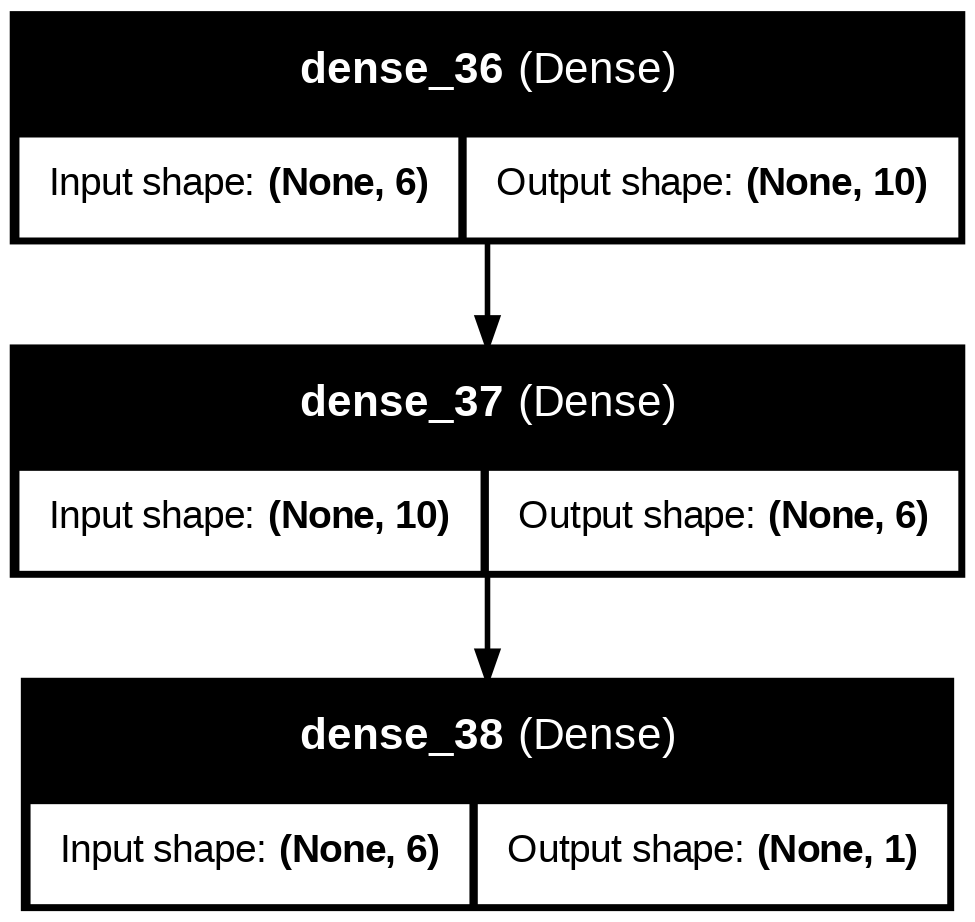

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431 (1.69 KB)

 Trainable params: 143 (572.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 288 (1.13 KB)

In [24]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display
# Use your synthetic fraud dataset creation function or load your data
def generate_synthetic_fraud_data(num_records=200):
    np.random.seed(42)
    data = []
    for _ in range(num_records):
        transaction_amount = np.round(np.random.uniform(1, 5000), 2)
        transaction_time = np.random.randint(0, 86400)
        merchant_category = np.random.randint(1, 11)
        customer_age = np.random.randint(18, 81)
        account_balance = np.round(np.random.uniform(0, 100000), 2)
        num_transactions_today = np.random.randint(0, 21)
        fraud_prob = 0.05
        if transaction_amount > 3000 and account_balance < 5000:
            fraud_prob += 0.4
        if transaction_time < 3600 or transaction_time > 82800:
            fraud_prob += 0.2
        if merchant_category in [7, 8, 9]:
            fraud_prob += 0.1
        if num_transactions_today > 15:
            fraud_prob += 0.15
        fraud = np.random.choice([0, 1], p=[1-fraud_prob, fraud_prob])
        data.append([
            transaction_amount,
            transaction_time,
            merchant_category,
            customer_age,
            account_balance,
            num_transactions_today,
            fraud
        ])
    columns = [
        'TransactionAmount',
        'TransactionTime',
        'MerchantCategory',
        'CustomerAge',
        'AccountBalance',
        'NumberOfTransactionsToday',
        'Fraud'
    ]
    return pd.DataFrame(data, columns=columns)
data = generate_synthetic_fraud_data(200)
# Features and target
X = data.drop('Fraud', axis=1).values
y = data['Fraud'].values
# Normalize features for better training
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Build a simple neural network model
model = Sequential([
    Dense(10, input_dim=X_scaled.shape[1], activation='relu'),
    Dense(6, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification output
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Train the model briefly
model.fit(X_scaled, y, epochs=20, batch_size=10, verbose=0)
# Visualize model architecture and save as PNG
plot_model(model, to_file='fraud_detection_nn_model.png', show_shapes=True, show_layer_names=True)
print("Neural network architecture saved as 'fraud_detection_nn_model.png'")
display(Image(filename='fraud_detection_nn_model.png'))

# Print a summary of the model (optional, but good for inspection)
model.summary()

In [25]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from keras_visualizer import visualizer
import os

In [26]:
features = data.drop(columns=['Fraud'])
target = data['Fraud']
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_train, features_test, target_train, target_test = train_test_split(
    features_scaled,
    target,
    test_size=0.2,
    random_state=827
)

In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    features_train,
    target_train,
    epochs=50,
    validation_split=0.1,
    batch_size=8,
    verbose=0
)

test_loss, test_acc = model.evaluate(features_test, target_test)
print(f"test loss: {test_loss}")
print(f"test accuracy: {test_acc}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9000 - loss: 0.4229 
test loss: 0.4228660464286804
test accuracy: 0.8999999761581421


Done
377695


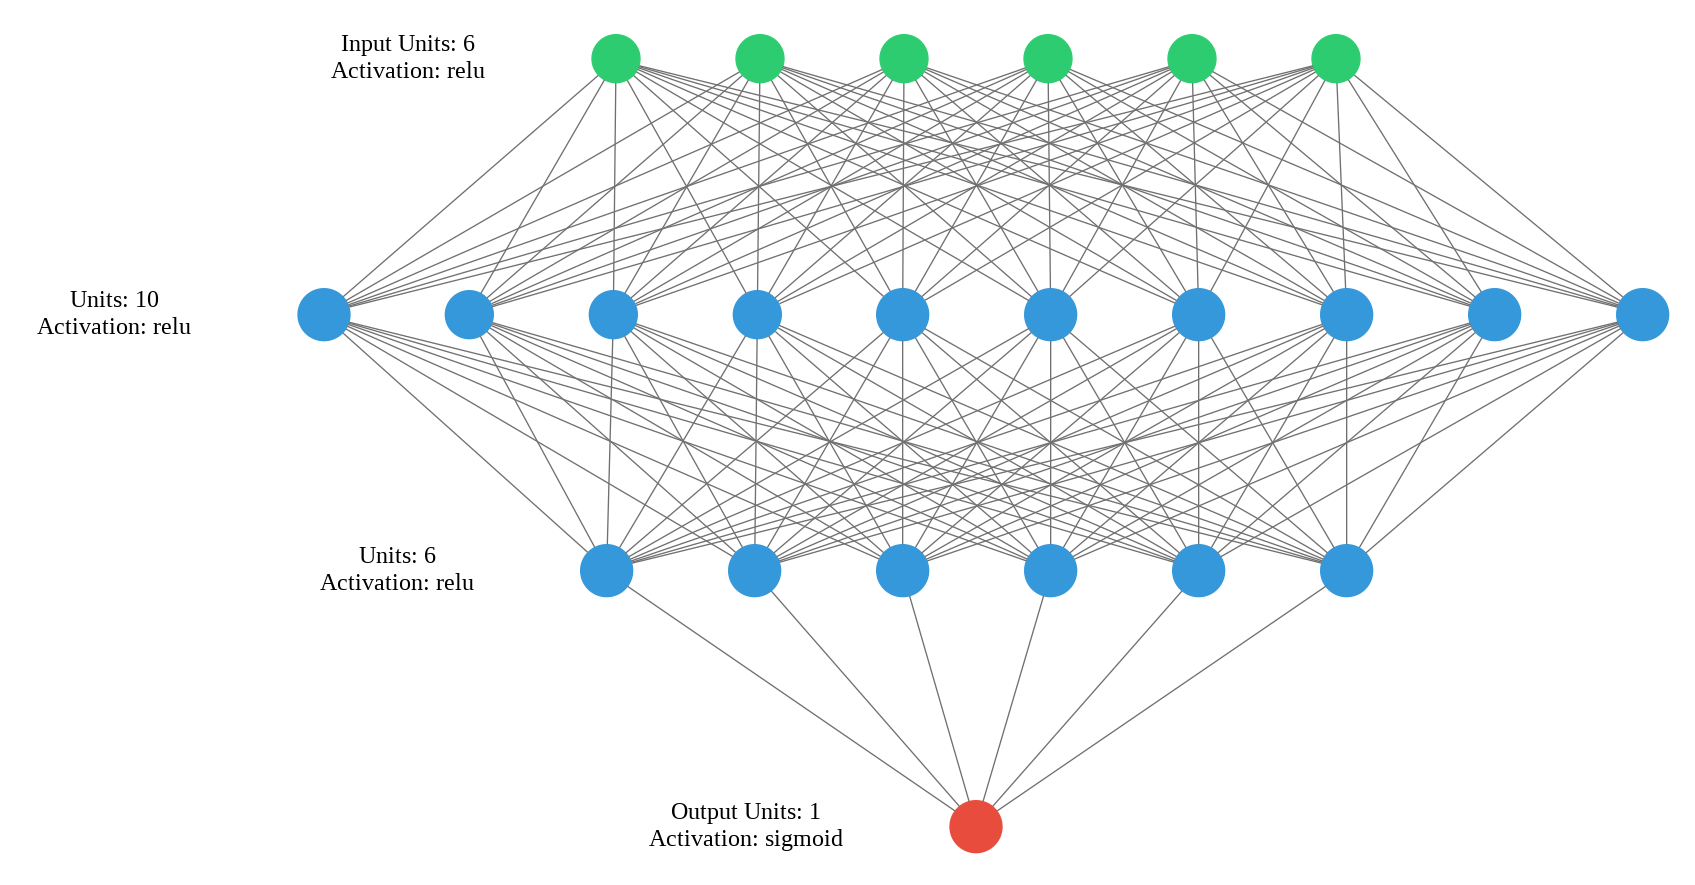

In [28]:
try:
    visualizer(
        model,
        "graph",
        file_format='png'
    )
    print("Done")
except Exception as e:
    print(type(e).__name__)
    print(e)

print(os.path.getsize("graph.png"))
Image('graph.png')
